In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
     return 3*x**2 - 4*x + 5

In [3]:
f(2.0)

9.0

In [4]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

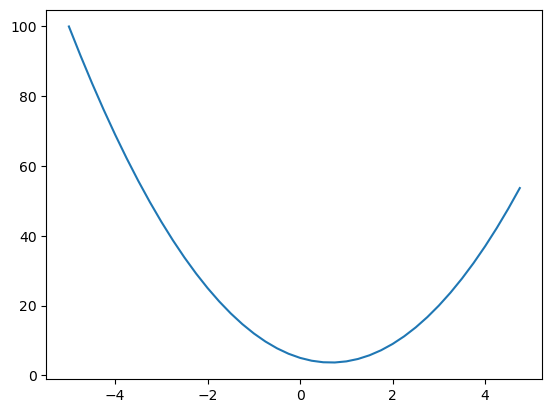

In [5]:
plt.plot(xs,ys)

### deravative function

In [11]:
x = 2
h = 0.01
(f(x+h) - f(x))

0.0802999999999976

In [12]:
(f(x+h) - f(x))/h

8.02999999999976

In [14]:
# les get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [15]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h  # chainging c by a little val how does d get affected
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


## Micrograd Class Objects

In [131]:
class Value:
    def __init__(self,data, _children=() , _op = '', label = ''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    
    def __add__(self,other):
        out = Value(self.data + other.data, (self, other), '*')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0*out.grad
        out._backward = _backward
        return out
    def __repr__(self):                      # wrapper to print the object else i will be like < value at 0x230fda1ffb0>
        return f"Value(data={self.data})"

    def __mul__(self,other):
        out =Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        
        return out

    def tanh(self):
        x = self.data 
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        def _backward():
            self.grad += 1 - t ** 2 * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []          # topological order with forward edges
        visited = set()
        def build_topo(v):
          if v not in visited:
            visited.add(v)
            for child in v._prev:  
              build_topo(child)   # first node in the begining
            topo.append(v)   
        build_topo(self)   # dont forgot to  call the function
        
        self.grad = 1.0      # set the last grad to 1 cause dL/dL is 1 
        for node in reversed(topo):
          node._backward()
            
        

In [133]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

In [135]:
L.backward()

## building the graph 

In [138]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

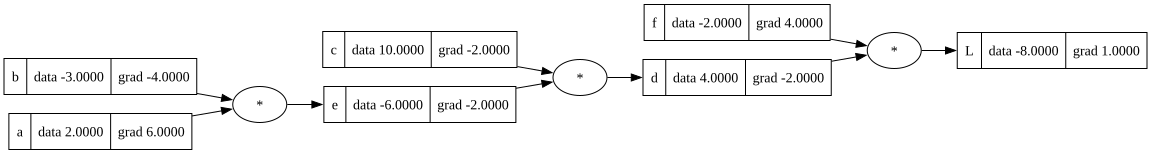

In [140]:
draw_dot(L)

In [32]:
import os

os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

## nudging the val toward the gradient

In [142]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-7.286496


## building a neuron

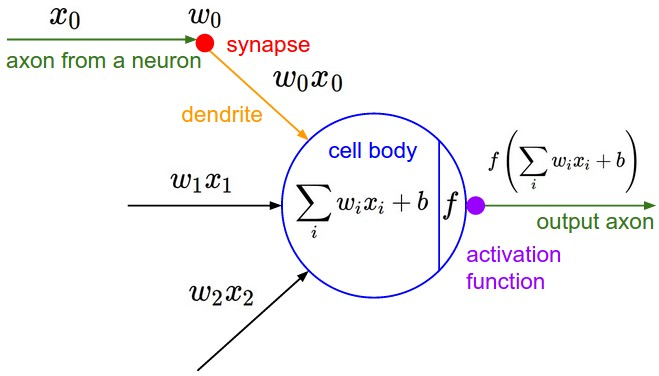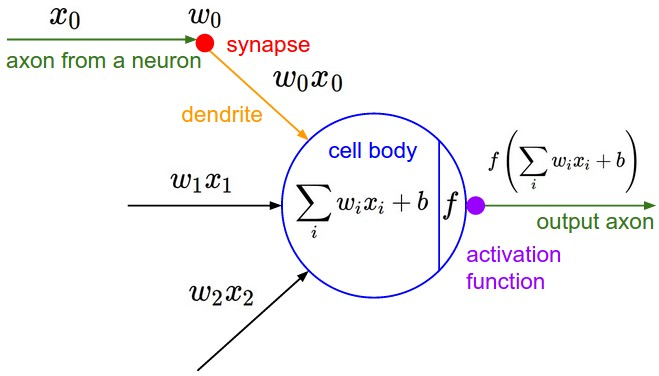

In [144]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1,w2 --- synapse
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron -- happines trigger
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'


n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'  # activation func

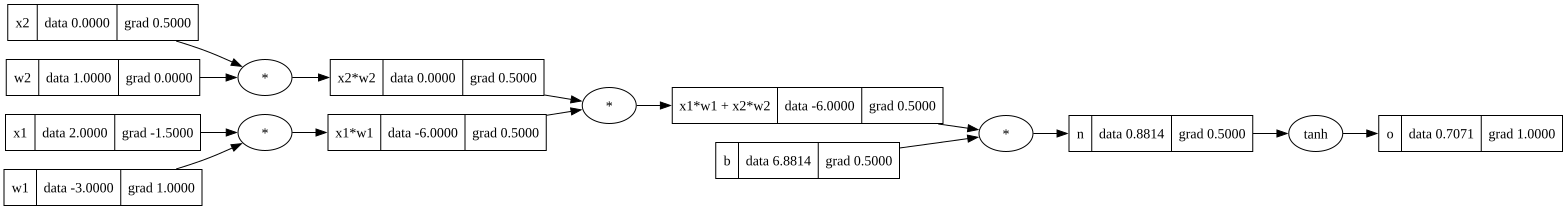

In [150]:
draw_dot(o)

In [148]:
o.backward()

In [169]:
class Value:
  
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')
    
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
      
    return out
  
  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out
  
  def __rmul__(self, other): # other * self    if int * val - our mul checks only if other is int , so this will swap and mul thats all
    return self * other

  def __truediv__(self, other): # self / other
    return self * other**-1

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def __radd__(self, other): # other + self
    return self + other

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    
    return out
  
  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')
    
    def _backward():
      self.grad += out.data * out.grad # NOTE: in the video I incorrectly used = instead of +=. Fixed here.
    out._backward = _backward
    
    return out
  
  
  def backward(self):
    
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

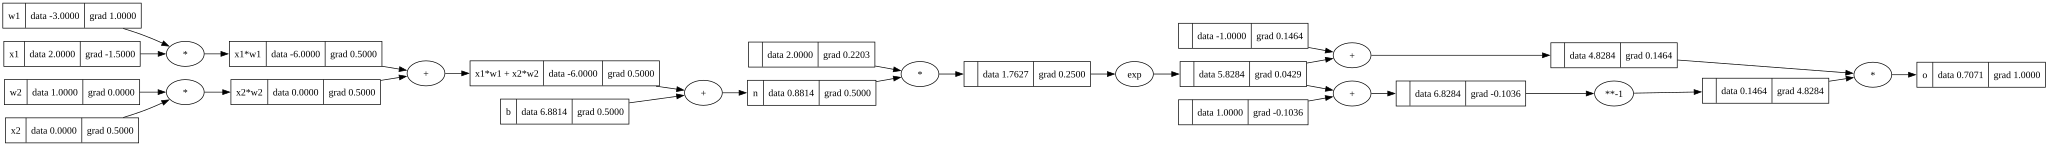

In [154]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# ----
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ----
o.label = 'o'
o.backward()
draw_dot(o)

## with pytorch api

In [157]:
import torch

In [159]:
x = torch.Tensor([2.0]).double()     # torch float32 - double -> float64 - python compatible

In [161]:
x

tensor([2.], dtype=torch.float64)

In [163]:
x.data.item()

2.0

In [165]:
x.item()

2.0

In [167]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True      #means it will store gradient for those tensor like for our val class we had self.grad
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [177]:
import math
import random

In [220]:
class Neuron:
    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
    def __call__(self,x):
        # w0x0 + w1x1 + b
        # either do a for loop over it all and mul add or
        act = sum((wi * xi for wi,xi in zip(self.w,x)),self.b) 
        out = act.tanh()
        return out
x = [2.0,3.0]
n = Neuron(2)   # since x dim is 2
n(x)  # python uses __call__ if we use x(x)
        

Value(data=-0.05723660355106812)

In [218]:
class Layer:
  
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

In [226]:
x = [2.0,3.0]
n = Layer(2,4)   # since x dim is 2
n(x) 

[Value(data=-0.9136143171855421),
 Value(data=-0.008339579969641107),
 Value(data=0.7227578304074491),
 Value(data=0.8373224070779873)]

In [316]:
class Neuron:
  
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))
  
  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
  
  def parameters(self):
    return self.w + [self.b]

class Layer:
  
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
  
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

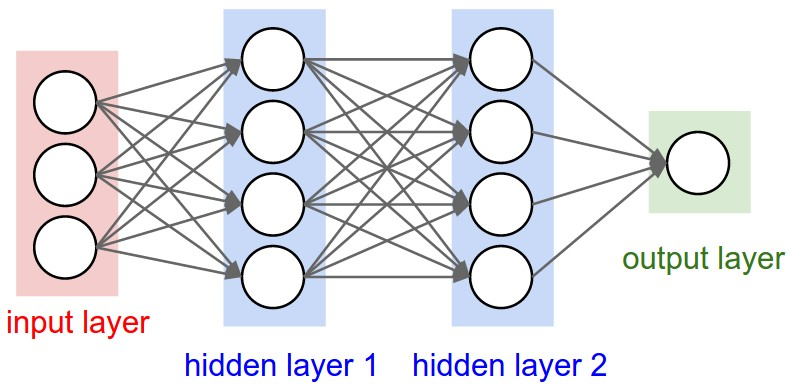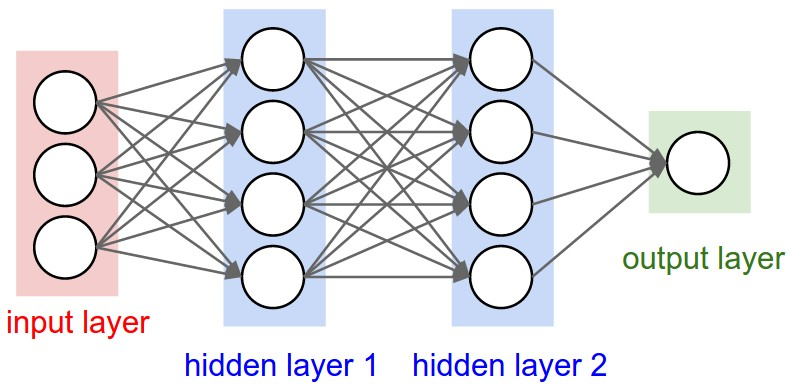

In [319]:
x = [2.0,3.0,-1.0]   # input
n = MLP(3, [4,4,1])   # nin input dim is 3 and output we have hd1 with 4 hd2 with 4 neurons and output as one neuron
n(x)  


Value(data=-0.2889093664495315)

In [321]:
'''
this function from MLP gets called 
def __call__(self, x):
    for layer in self.layers:
      x = layer(x)     # here its self.layers that is self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))] so Layer fun gets called
    return x
'''

'''
 Layer(sz[i] --> input dim nin and s[i+1] is the consecutive next output of neurons 

'''

'\n Layer(sz[i] --> input dim nin and s[i+1] is the consecutive next output of neurons \n\n'

In [323]:
x = [2.0,3.0,-1.0]   # input
n = MLP(3, [4,4,1])   # nin input dim is 3 and output we have hd1 with 4 hd2 with 4 neurons and output as one neuron
n(x)  


Value(data=0.5557024645699923)

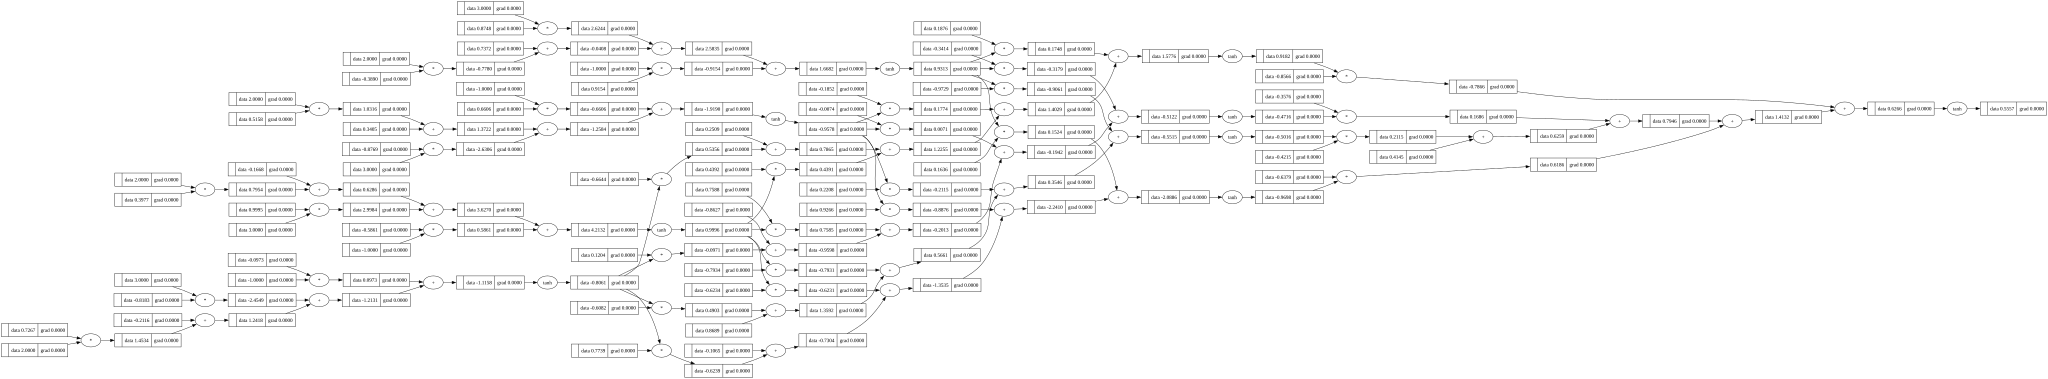

In [324]:
draw_dot(n(x))

## creating a mock dataset

In [328]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0,-1.0,-1.0,1.0]   # for first row in x it is 1 second it is -1 - like a binary classifier
# testing the random weights of the neuron first
ypred = [n(x) for x in xs]

In [330]:
ypred

[Value(data=0.5557024645699923),
 Value(data=0.2528335375194273),
 Value(data=0.23289771530931144),
 Value(data=0.4622887119141142)]

In [332]:
loss = [(xp - xi)**2 for xp,xi in zip(ypred,ys)]

In [334]:
loss

[Value(data=0.19740029998917896),
 Value(data=1.5695918727334421),
 Value(data=1.52003677641492),
 Value(data=0.28913342933498254)]

In [336]:
loss = sum([(xp - xi)**2 for xp,xi in zip(ypred,ys)])
loss

Value(data=3.5761623784725236)

In [338]:
loss.backward()

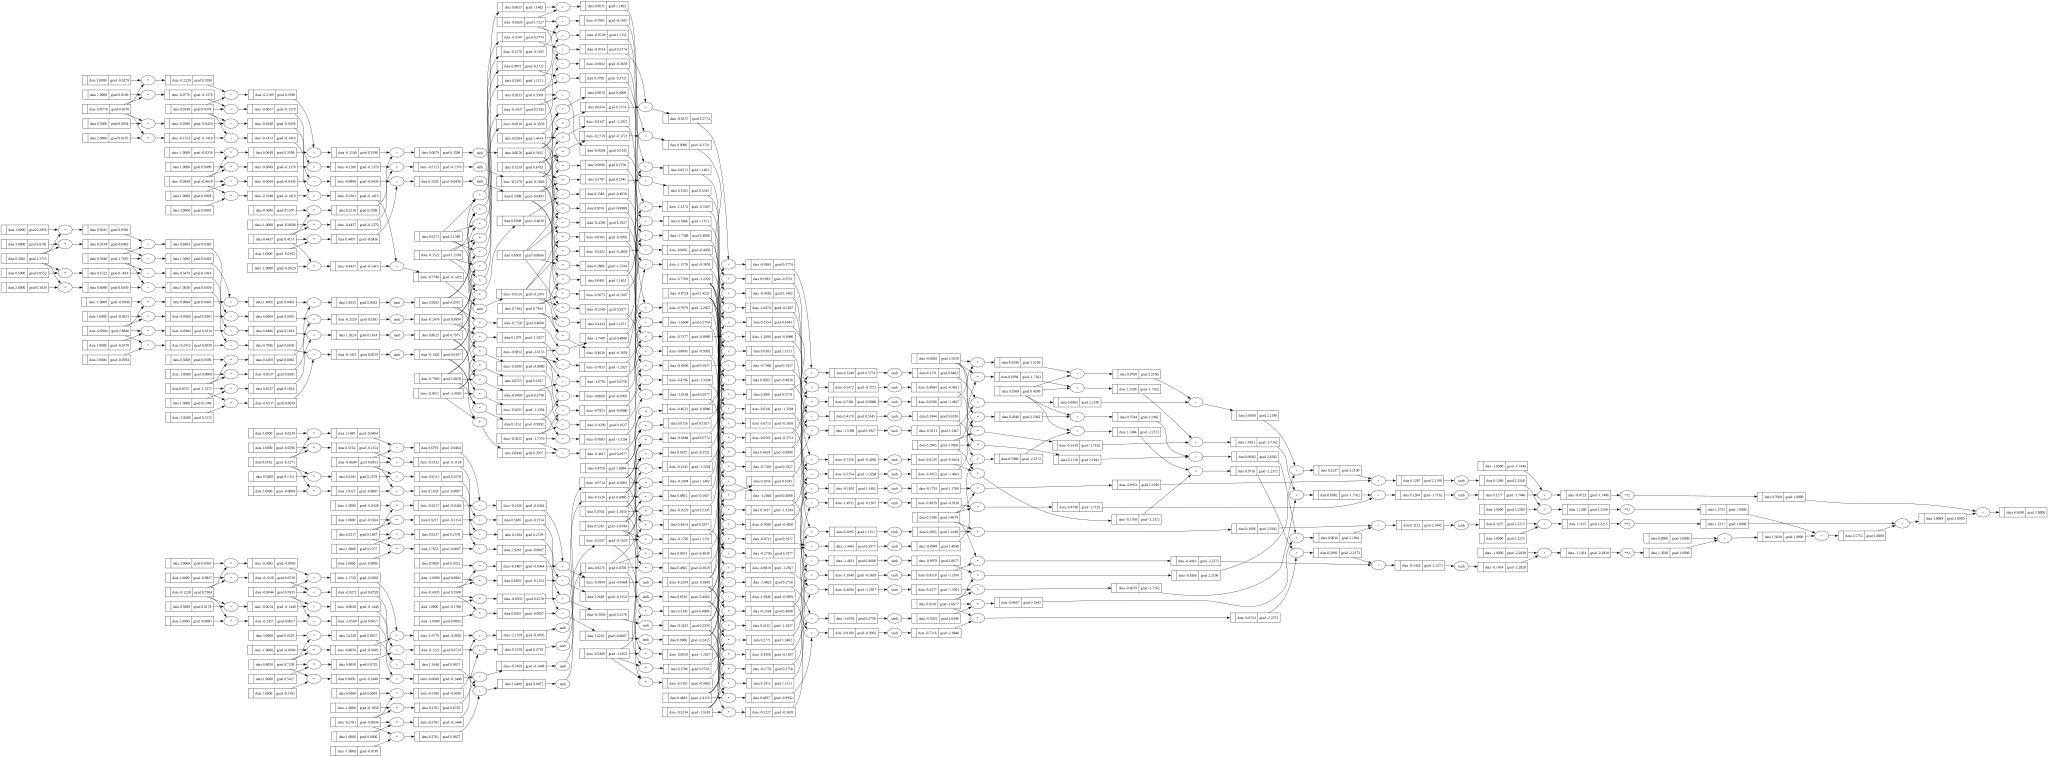

In [302]:
draw_dot(loss)

In [342]:
n.layers[0].neurons[0].w

[Value(data=0.8358833775397452),
 Value(data=-0.68526293542648),
 Value(data=-0.2002902108586385)]

In [340]:
for k in range(20):
  
  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
  
  # backward pass
  for p in n.parameters():
    p.grad = 0.0   # we need to flush the old grads for every new pass since our grads accumulate += 
  loss.backward()
  
  # update
  for p in n.parameters():
    p.data += -0.1 * p.grad
  
  print(k, loss.data)

0 3.5761623784725236
1 0.5876277613758316
2 0.21305415864814525
3 0.10963043226710398
4 0.08316370027424153
5 0.06688699064128244
6 0.055830191166945785
7 0.0478374608987539
8 0.04179760773872761
9 0.03707785524503103
10 0.033291376297246246
11 0.030188510019688898
12 0.027601015102145108
13 0.025411447165452176
14 0.02353537549450578
15 0.02191057217950675
16 0.020490182293149542
17 0.01923826517955049
18 0.018126799953260223
19 0.01713362394043099


In [346]:
ypred  #walaaaaaahhhhhh

[Value(data=0.9453735871151645),
 Value(data=-0.9403705529585977),
 Value(data=-0.9312638975737465),
 Value(data=0.9233889288382504)]

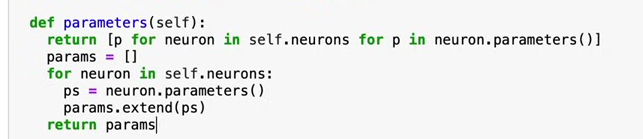

In [351]:
n.parameters()

[Value(data=0.8358833775397452),
 Value(data=-0.68526293542648),
 Value(data=-0.2002902108586385),
 Value(data=-0.12540635957286916),
 Value(data=0.46243351255265147),
 Value(data=0.7602055554923604),
 Value(data=-0.7709503776650547),
 Value(data=-0.30391647184446297),
 Value(data=0.5080313397974504),
 Value(data=-0.7903374457969053),
 Value(data=0.9632343575434253),
 Value(data=0.4366356691471599),
 Value(data=-0.33566720418244556),
 Value(data=0.9824837195273256),
 Value(data=0.8168703316662441),
 Value(data=0.808556301946628),
 Value(data=-0.637351728369638),
 Value(data=-0.9372018665074414),
 Value(data=0.4883855224108251),
 Value(data=-0.9350227755453311),
 Value(data=0.8940419311510096),
 Value(data=0.17500836912586762),
 Value(data=0.6955463109544786),
 Value(data=0.1176766825237726),
 Value(data=-0.3795977563685085),
 Value(data=-0.8297596895237165),
 Value(data=0.6676652408936783),
 Value(data=-0.669110388645945),
 Value(data=1.1527998757706517),
 Value(data=0.3136183272465949

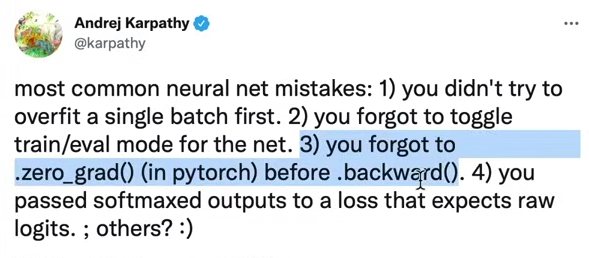